In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, matthews_corrcoef,
                             precision_recall_curve, roc_curve, auc,
                             confusion_matrix)
import shap

warnings.filterwarnings("ignore")
print("Libraries loaded")

Libraries loaded


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
save_dir = "/content/drive/MyDrive/models"

In [ ]:
from google.colab import files

uploaded = files.upload()
df = pd.read_csv("dataset_modified.csv")
print("Shape:", df.shape)
df.head()

Saving dataset_modified.csv to dataset_modified (1).csv
Shape: (9000, 9)


,experiment,cpu,run_id,mem_before_kb,mem_after_kb,irq_before,irq_after,softirq_before,softirq_after
0,1,1,run_001,81036.0,NaN,2.394890e+05,1.830777e+09,NaN,NaN
1,1,1,run_002,81032.0,NaN,2.132530e+05,1.829719e+09,NaN,NaN
2,1,1,run_003,81004.0,NaN,1.584081e+10,1.829229e+09,NaN,NaN
3,1,1,run_004,81032.0,NaN,1.816470e+05,1.829501e+09,NaN,NaN
4,1,1,run_005,81044.0,NaN,1.073004e+06,1.830106e+09,NaN,NaN


In [ ]:
# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fill missing numeric values
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print("Columns:", list(df.columns))
print("Shape after cleaning:", df.shape)
df.info()

Columns: ['experiment', 'cpu', 'run_id', 'mem_before_kb', 'mem_after_kb', 'irq_before', 'irq_after', 'softirq_before', 'softirq_after']
Shape after cleaning: (9000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   experiment      9000 non-null   int64  
 1   cpu             9000 non-null   int64  
 2   run_id          9000 non-null   object 
 3   mem_before_kb   9000 non-null   float64
 4   mem_after_kb    9000 non-null   float64
 5   irq_before      9000 non-null   float64
 6   irq_after       9000 non-null   float64
 7   softirq_before  9000 non-null   float64
 8   softirq_after   9000 non-null   float64
dtypes: float64(6), int64(2), object(1)
memory usage: 632.9+ KB


In [ ]:
possible_cols = ['experiment', 'experiment_id', 'exp', 'label', 'class', 'scenario']
exp_col = next((c for c in possible_cols if c in df.columns), None)

if exp_col is None:
    raise Exception("No experiment column found!")
print("Using experiment column:", exp_col)

# Convert to int
df[exp_col] = pd.to_numeric(df[exp_col], errors='coerce')
df.dropna(subset=[exp_col], inplace=True)
df[exp_col] = df[exp_col].astype(int)

# Mapping
exp_mapping = {
    1: "Normal",
    2: "CPU_Saturation",
    3: "Interrupt_Stress",
    4: "Memory_Pressure",
    5: "Mixed_Load",
    6: "True_Interrupt_Storm"
}

df['anomaly_type'] = df[exp_col].map(exp_mapping)
df['anomaly_flag'] = np.where(df[exp_col] == 1, 0, 1)

print("\nLabel distribution:")
print(df['anomaly_type'].value_counts())

Using experiment column: experiment

Label distribution:
anomaly_type
Normal                  1500
CPU_Saturation          1500
Interrupt_Stress        1500
Memory_Pressure         1500
Mixed_Load              1500
True_Interrupt_Storm    1500
Name: count, dtype: int64


In [ ]:
# Separate features and labels
X = df.drop([exp_col, 'anomaly_type', 'anomaly_flag'], axis=1)
y_det = df['anomaly_flag']
y_cls = df['anomaly_type']

print("Feature shape:", X.shape)

# Encode categorical columns
X_encoded = X.copy()
encoders = {}
cat_cols = X_encoded.select_dtypes(exclude=np.number).columns
print("Encoding:", list(cat_cols))

for col in cat_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    encoders[col] = le

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print("Encoding and scaling done")

Feature shape: (9000, 8)
Encoding: ['run_id']
Encoding and scaling done


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

# StratifiedShuffleSplit guarantees BOTH classes in train AND test
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in sss.split(X_scaled, y_det):
    X_tr_det = X_scaled[train_idx]
    X_te_det = X_scaled[test_idx]
    y_tr_det = y_det.iloc[train_idx]
    y_te_det = y_det.iloc[test_idx]

print(f"Train → {X_tr_det.shape} | Normal: {(y_tr_det==0).sum()} | Anomaly: {(y_tr_det==1).sum()}")
print(f"Test  → {X_te_det.shape} | Normal: {(y_te_det==0).sum()} | Anomaly: {(y_te_det==1).sum()}")

Train → (7200, 8) | Normal: 1200 | Anomaly: 6000
Test  → (1800, 8) | Normal: 300 | Anomaly: 1500


In [ ]:
print("=== Class Distribution ===")
print(f"Training set:\n{pd.Series(y_tr_det).value_counts()}")
print(f"\nTest set:\n{pd.Series(y_te_det).value_counts()}")

# This will expose the problem immediately
train_score = det_model.score(X_tr_det, y_tr_det)
test_score  = det_model.predict(X_te_det)

print(f"\nIf model predicts ALL as Anomaly:")
print(f"Accuracy would be: {(y_te_det == 1).mean():.4f}")  # baseline
print(f"Your model needs to beat this meaningfully")

=== Class Distribution ===
Training set:
anomaly_flag
1    6000
0    1200
Name: count, dtype: int64

Test set:
anomaly_flag
1    1500
0     300
Name: count, dtype: int64

If model predicts ALL as Anomaly:
Accuracy would be: 0.8333
Your model needs to beat this meaningfully


In [ ]:
# ===============================
# Detection Model - Imbalance-Aware Grid
# ===============================
RETRAIN = False  # set False after first run

if RETRAIN:
    from sklearn.model_selection import StratifiedKFold
    from imblearn.over_sampling import SMOTE

    # --- Fix the imbalance BEFORE training ---
    print("Class counts before SMOTE:", pd.Series(y_tr_det).value_counts().to_dict())

    smote = SMOTE(random_state=42)
    X_tr_det_bal, y_tr_det_bal = smote.fit_resample(X_tr_det, y_tr_det)

    print("Class counts after SMOTE:", pd.Series(y_tr_det_bal).value_counts().to_dict())

    # --- Tighter, regularized param grid ---
    param_grid_det = {
        "n_estimators":      [200, 300],
        "max_depth":         [5, 8, 10],    # much shallower — prevents memorization
        "min_samples_split": [20, 50],      # forces meaningful splits
        "min_samples_leaf":  [10, 20],      # prevents tiny overfit leaves
        "max_features":      ["sqrt"],
        "max_samples":       [0.7, 0.8],    # subsample rows per tree
        "class_weight":      ["balanced"]   # double protection with SMOTE
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    grid_det = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid_det,
        cv=skf,
        scoring="f1",                   # f1 is robust to imbalance unlike accuracy
        n_jobs=-1,
        verbose=2,
        return_train_score=True         # lets you inspect the gap
    )

    grid_det.fit(X_tr_det_bal, y_tr_det_bal)  # train on balanced data
    det_model = grid_det.best_estimator_

    # Check train vs val gap
    best_idx = grid_det.best_index_
    cv_train = grid_det.cv_results_['mean_train_score'][best_idx]
    cv_val   = grid_det.cv_results_['mean_test_score'][best_idx]
    print(f"\nCV Train F1 : {cv_train:.4f}")
    print(f"CV Val   F1 : {cv_val:.4f}")
    print(f"Gap         : {cv_train - cv_val:.4f}  ← should be < 0.05")

    joblib.dump(det_model,             f"{save_dir}/det_model.pkl")
    joblib.dump(grid_det.best_params_, f"{save_dir}/best_params_det.pkl")
    print("\n✅ Detection model saved!")

else:
    det_model = joblib.load(f"{save_dir}/det_model.pkl")
    print("✅ Loaded from disk:", joblib.load(f"{save_dir}/best_params_det.pkl"))

✅ Loaded from disk: {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'max_samples': 0.8, 'min_samples_leaf': 10, 'min_samples_split': 20, 'n_estimators': 300}


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder

# --- Classification split (anomalous samples only) ---
# Filter to anomaly rows only for classification
anomaly_mask = y_det == 1
X_anomaly = X_scaled[anomaly_mask]
y_anomaly = y_cls[anomaly_mask]  # multi-class labels

# Encode the anomaly type labels
le_cls = LabelEncoder()
y_anomaly_enc = le_cls.fit_transform(y_anomaly)

# Stratified split
sss_cls = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in sss_cls.split(X_anomaly, y_anomaly_enc):
    X_tr_cls = X_anomaly[train_idx]
    X_te_cls = X_anomaly[test_idx]
    y_tr_cls = y_anomaly_enc[train_idx]
    y_te_cls = y_anomaly_enc[test_idx]

print(f"Classification Train → {X_tr_cls.shape}")
print(f"Classification Test  → {X_te_cls.shape}")
print(f"Classes: {le_cls.classes_}")

Classification Train → (6000, 8)
Classification Test  → (1500, 8)
Classes: ['CPU_Saturation' 'Interrupt_Stress' 'Memory_Pressure' 'Mixed_Load'
 'True_Interrupt_Storm']


=== Detection Evaluation ===

Classes in test set: [np.int64(0), np.int64(1)]  ← must be [0, 1]

              precision    recall  f1-score   support

      Normal       0.83      1.00      0.91       300
     Anomaly       1.00      0.96      0.98      1500

    accuracy                           0.97      1800
   macro avg       0.91      0.98      0.94      1800
weighted avg       0.97      0.97      0.97      1800

MCC: 0.8907  ← key metric, >0.7 is good
AUPRC:   0.9997  ← most important for imbalanced data
ROC AUC: 0.9984


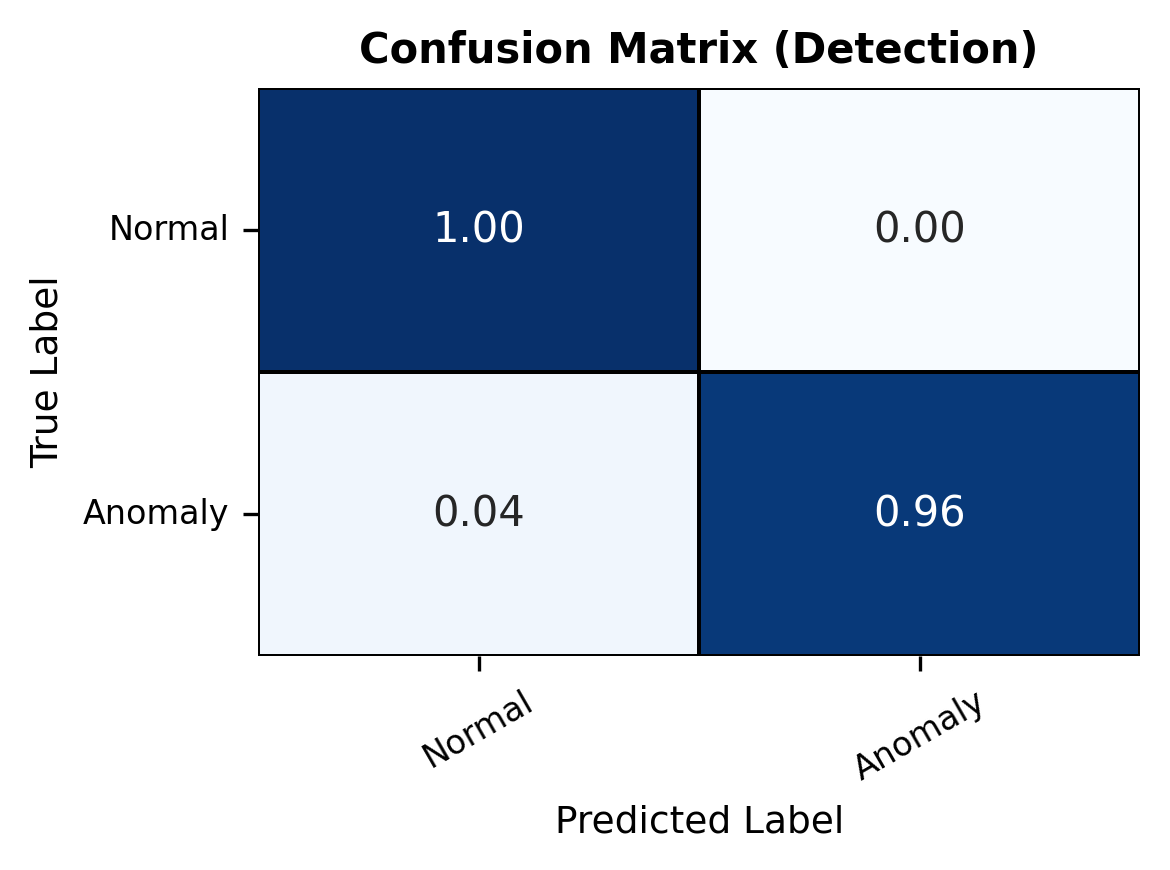

In [ ]:
from sklearn.metrics import (classification_report, matthews_corrcoef,
                             precision_recall_curve, roc_curve, auc,
                             confusion_matrix)

y_pred_det = det_model.predict(X_te_det)
y_prob_det = det_model.predict_proba(X_te_det)[:, 1]

# Check what classes are actually in test set before reporting
unique_classes = sorted(y_te_det.unique())
target_names   = ["Normal" if c == 0 else "Anomaly" for c in unique_classes]

print("=== Detection Evaluation ===\n")
print(f"Classes in test set: {unique_classes}  ← must be [0, 1]")
print()
print(classification_report(y_te_det, y_pred_det,
                             labels=unique_classes,
                             target_names=target_names))

mcc = matthews_corrcoef(y_te_det, y_pred_det)
print(f"MCC: {mcc:.4f}  ← key metric, >0.7 is good")

# Only compute curve metrics if both classes present
if len(unique_classes) == 2:
    precision, recall, _ = precision_recall_curve(y_te_det, y_prob_det)
    auprc   = auc(recall, precision)
    fpr, tpr, _ = roc_curve(y_te_det, y_prob_det)
    roc_auc = auc(fpr, tpr)
    print(f"AUPRC:   {auprc:.4f}  ← most important for imbalanced data")
    print(f"ROC AUC: {roc_auc:.4f}")

    # Confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Check if both classes exist
if len(np.unique(y_te_det)) > 1:

    # Compute confusion matrix
    cm = confusion_matrix(y_te_det, y_pred_det)

    # Normalize (recommended for paper)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Plot (IEEE size)
    plt.figure(figsize=(4, 3), dpi=300)

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        cbar=False,
        xticklabels=target_names,
        yticklabels=target_names,
        linewidths=0.5,
        linecolor='black'
    )

    # Labels
    plt.xlabel('Predicted Label', fontsize=9)
    plt.ylabel('True Label', fontsize=9)
    plt.title('Confusion Matrix (Detection)', fontsize=10, fontweight='bold')

    # Ticks
    plt.xticks(rotation=30, fontsize=8)
    plt.yticks(rotation=0, fontsize=8)

    # Layout
    plt.tight_layout()

    # Save image (important for paper)
    plt.savefig("confusion_matrix_Det.png", dpi=300, bbox_inches='tight')

    plt.show()

else:
    print("Only one class in test set — check your split above")

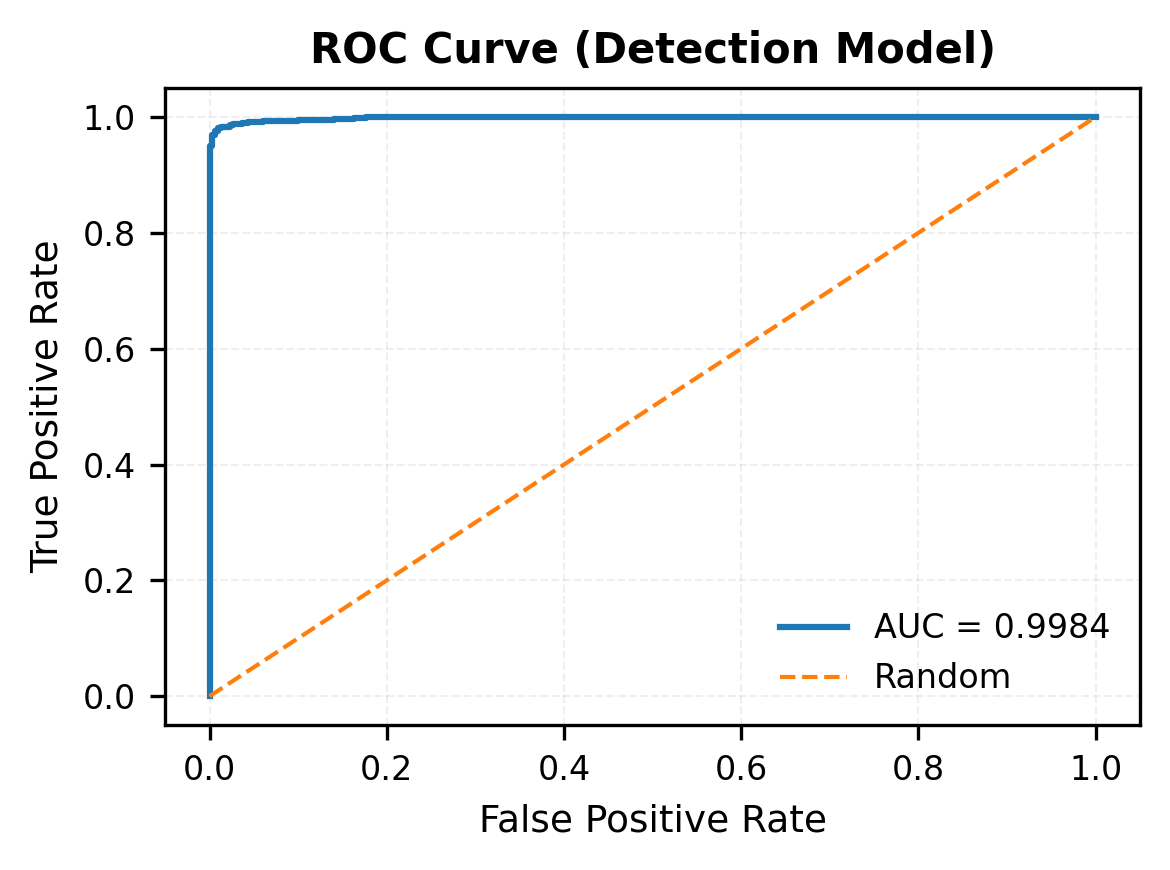

ROC AUC : 0.9984
Interpretation:
  > 0.90 → Excellent
  > 0.80 → Good
  > 0.70 → Fair
  = 0.50 → Random (model learned nothing)


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilities
y_prob_det = det_model.predict_proba(X_te_det)[:, 1]

# ROC computation
fpr, tpr, thresholds = roc_curve(y_te_det, y_prob_det)
roc_auc = auc(fpr, tpr)

# Figure (compact for IEEE 1-column)
plt.figure(figsize=(4, 3), dpi=300)

# ROC curve
plt.plot(fpr, tpr, lw=1.5, label=f"AUC = {roc_auc:.4f}")

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--', lw=1, label="Random")

# Axis labels
plt.xlabel("False Positive Rate", fontsize=9)
plt.ylabel("True Positive Rate", fontsize=9)

# Title
plt.title("ROC Curve (Detection Model)", fontsize=10, fontweight='bold')

# Ticks
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

# Grid (subtle)
plt.grid(alpha=0.2, linestyle='--', linewidth=0.5)

# Legend
plt.legend(loc="lower right", fontsize=8, frameon=False)

# Tight layout for paper fit
plt.tight_layout()

# Save high-quality figure
plt.savefig("roc_curve_ieee.png", dpi=300, bbox_inches='tight')

plt.show()

print(f"ROC AUC : {roc_auc:.4f}")
print(f"Interpretation:")
print(f"  > 0.90 → Excellent")
print(f"  > 0.80 → Good")
print(f"  > 0.70 → Fair")
print(f"  = 0.50 → Random (model learned nothing)")

In [ ]:
RETRAIN = False
if RETRAIN:
    print("🔍 Running GridSearch for Classification Model...")

    param_grid_cls = {
        "n_estimators":      [200, 300, 400],
        "max_depth":         [10, 15, 20],
        "min_samples_split": [5, 10],
        "min_samples_leaf":  [2, 5],
        "max_features":      ["sqrt", "log2"]
    }

    grid_cls = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid_cls,
        cv=5, scoring="f1_weighted",
        n_jobs=-1, verbose=2
    )
    grid_cls.fit(X_tr_cls, y_tr_cls)

    clf = grid_cls.best_estimator_

    # Save everything needed for inference
    joblib.dump(clf,               f"{save_dir}/clf_model.pkl")
    joblib.dump(grid_cls.best_params_, f"{save_dir}/best_params_cls.pkl")
    joblib.dump(scaler,            f"{save_dir}/scaler.pkl")
    joblib.dump(encoders,          f"{save_dir}/encoders.pkl")
    joblib.dump(le_cls,            f"{save_dir}/le_cls.pkl")
    joblib.dump(list(X.columns),   f"{save_dir}/feature_columns.pkl")

    print("\nClassification model + all components saved!")
    print("Best params:", grid_cls.best_params_)

else:
    clf      = joblib.load(f"{save_dir}/clf_model.pkl")
    scaler   = joblib.load(f"{save_dir}/scaler.pkl")
    encoders = joblib.load(f"{save_dir}/encoders.pkl")
    le_cls   = joblib.load(f"{save_dir}/le_cls.pkl")
    best_params_cls = joblib.load(f"{save_dir}/best_params_cls.pkl")
    print("Classification model loaded from disk!")
    print("Frozen params:", best_params_cls)

Classification model loaded from disk!
Frozen params: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}


=== Classification Report ===
                      precision    recall  f1-score   support

      CPU_Saturation       0.99      1.00      1.00       300
    Interrupt_Stress       1.00      1.00      1.00       300
     Memory_Pressure       1.00      1.00      1.00       300
          Mixed_Load       1.00      0.99      1.00       300
True_Interrupt_Storm       1.00      1.00      1.00       300

            accuracy                           1.00      1500
           macro avg       1.00      1.00      1.00      1500
        weighted avg       1.00      1.00      1.00      1500



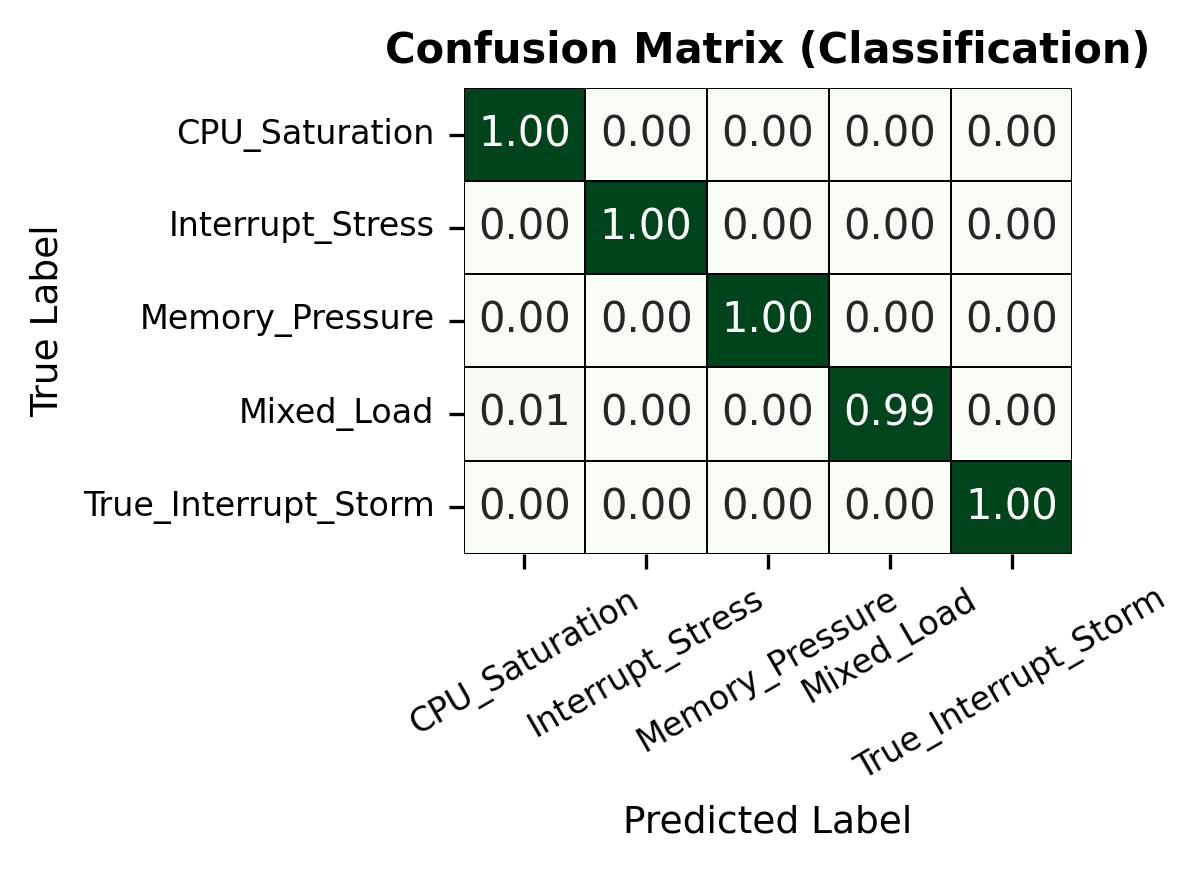

In [ ]:
y_pred_cls = clf.predict(X_te_cls)

print("=== Classification Report ===")
print(classification_report(y_te_cls, y_pred_cls, target_names=le_cls.classes_))

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Safety check: avoid division error
cm_cls = confusion_matrix(y_te_cls, y_pred_cls)

if cm_cls.sum(axis=1).min() == 0:
    print("⚠️ Warning: One class has zero samples in test set")
    cm_norm = cm_cls
else:
    # Normalize
    cm_norm = cm_cls.astype('float') / cm_cls.sum(axis=1)[:, np.newaxis]

# Plot (IEEE size)
plt.figure(figsize=(4, 3), dpi=300)

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    cbar=False,
    xticklabels=le_cls.classes_,
    yticklabels=le_cls.classes_,
    linewidths=0.4,
    linecolor='black'
)

# Labels & title
plt.title("Confusion Matrix (Classification)", fontsize=10, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=9)
plt.ylabel("True Label", fontsize=9)

# Tick formatting
plt.xticks(rotation=30, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

# Layout
plt.tight_layout()

# Save (high quality)
plt.savefig("confusion_matrix_classification.png", dpi=300, bbox_inches='tight')

plt.show()

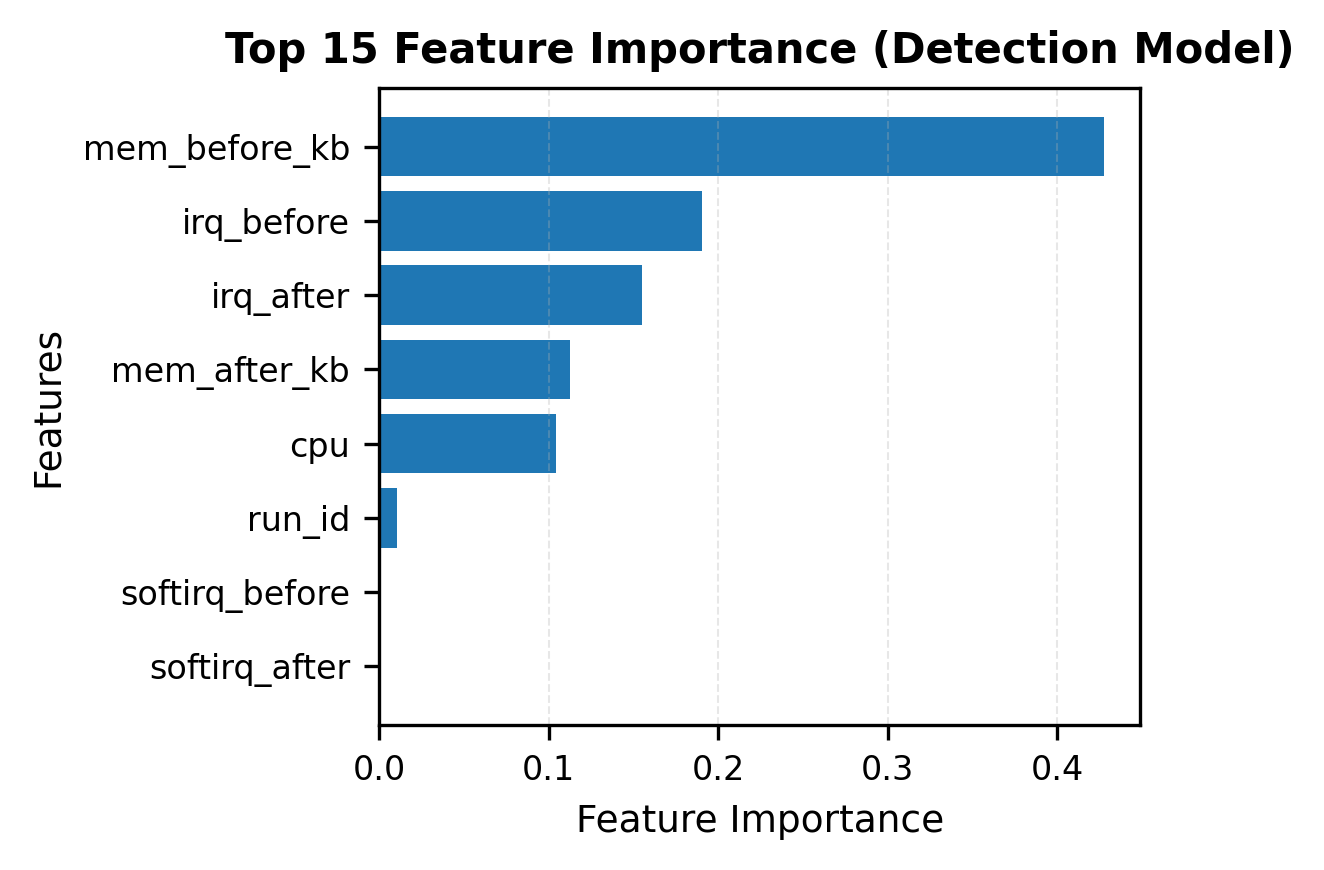

SHAP shape: (200, 8)
X shape   : (200, 8)


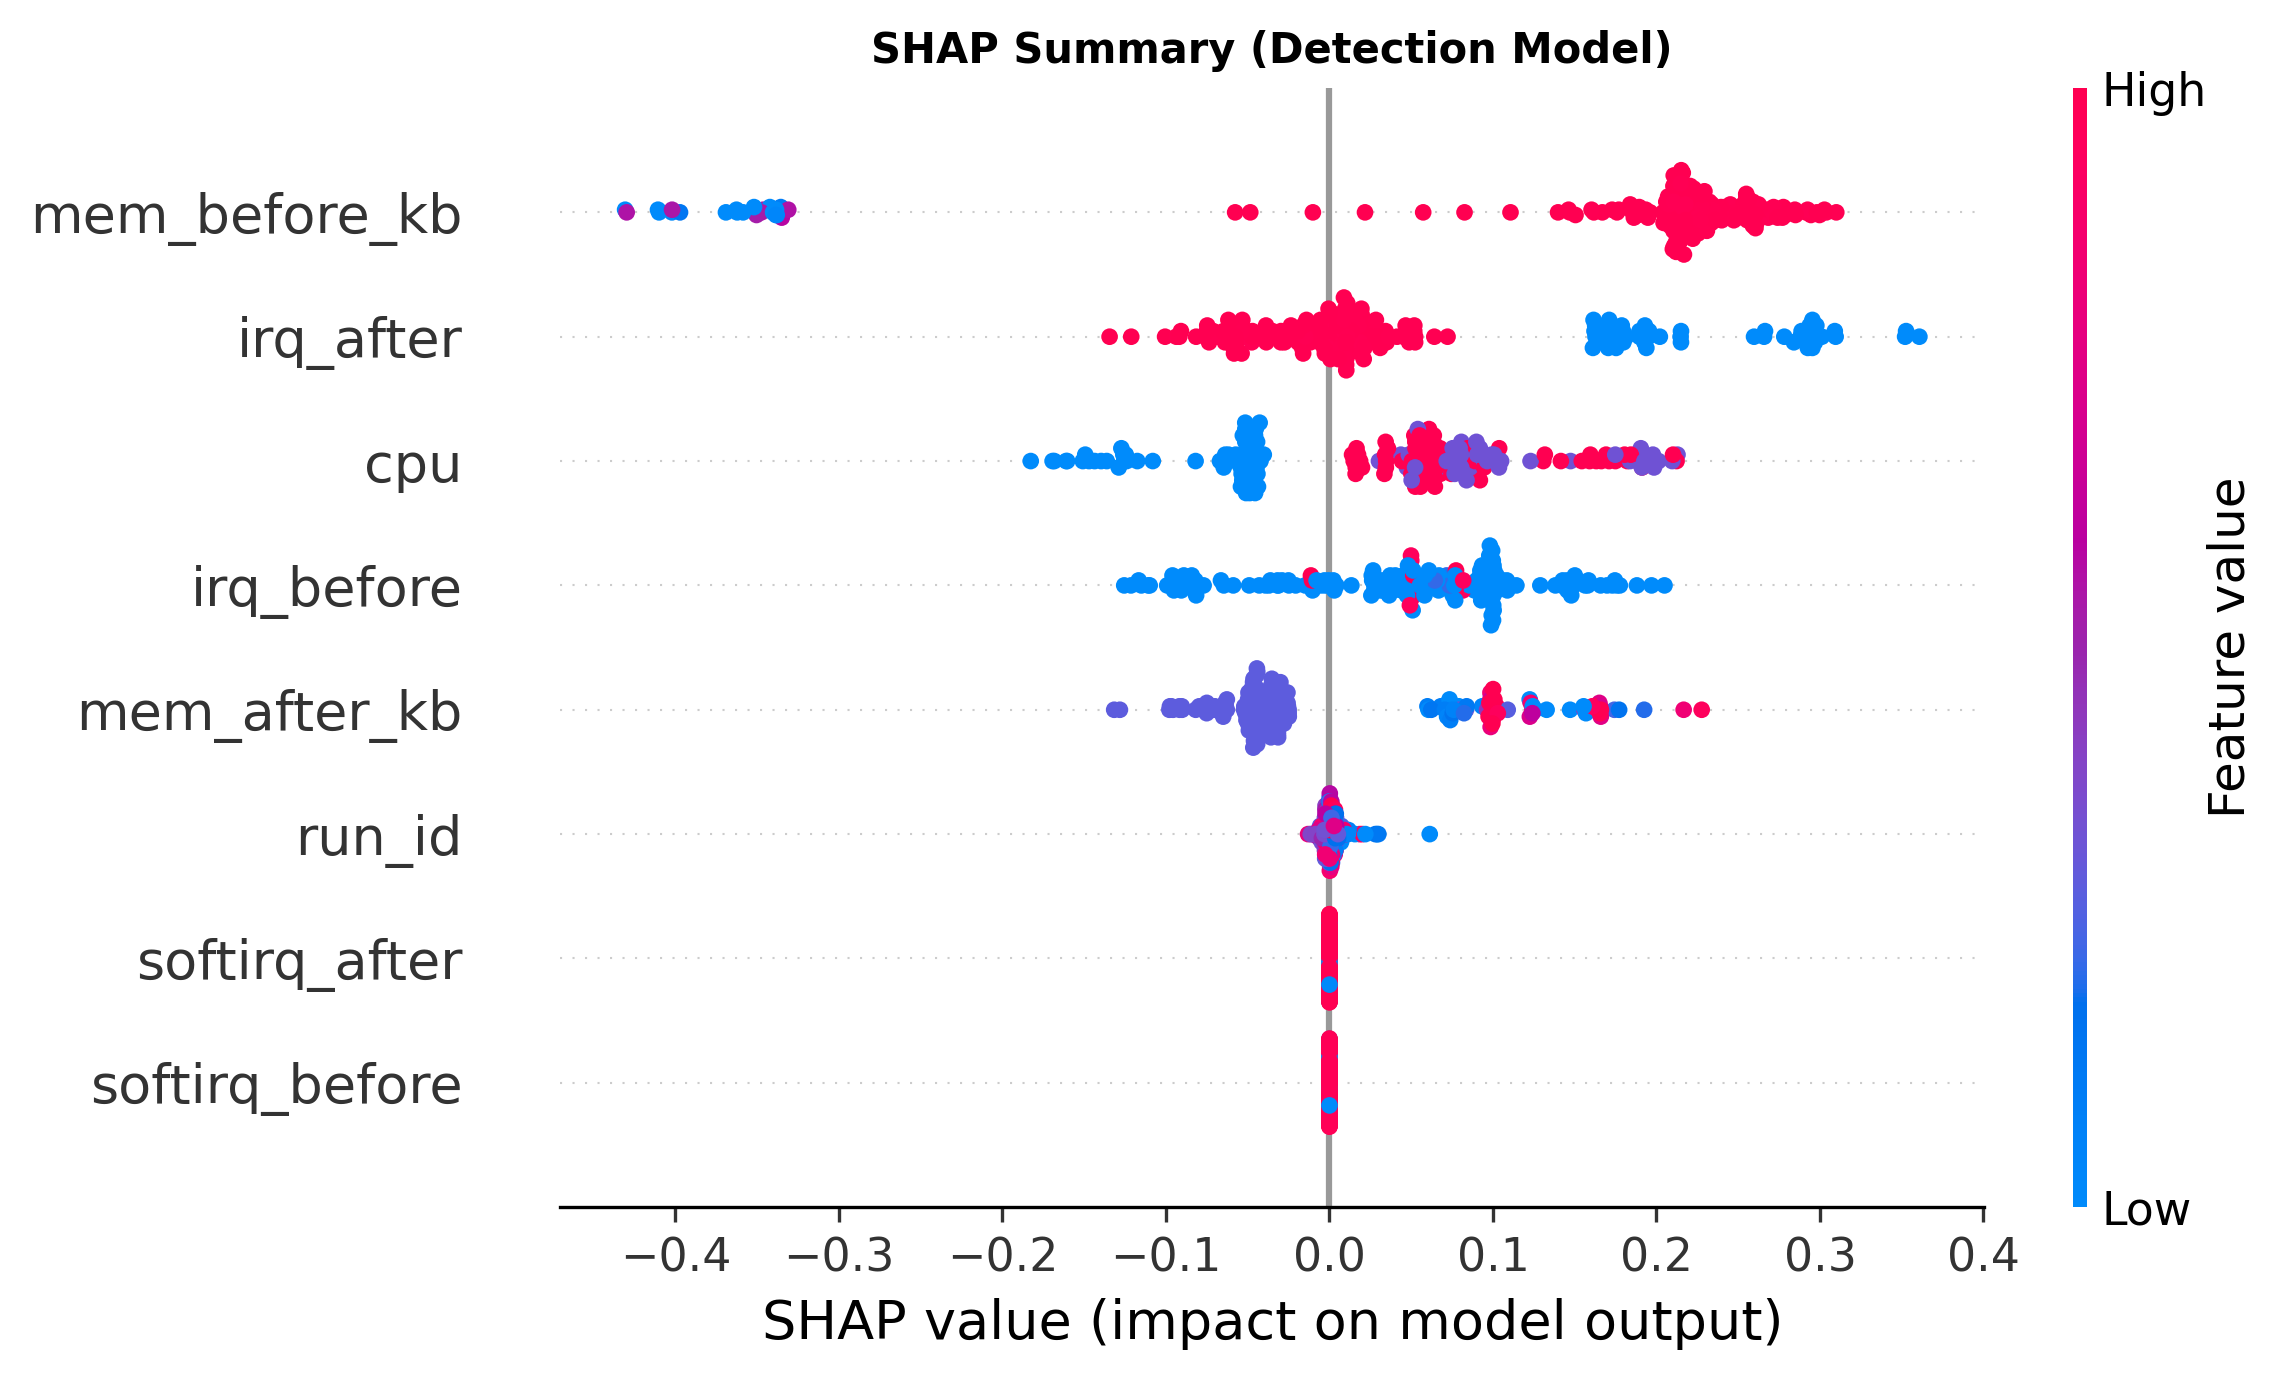

In [ ]:
# Feature Importance (Detection Model)
# Prepare dataframe
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": det_model.feature_importances_
}).sort_values("Importance", ascending=False)

# Select top 15
top_feat = feat_imp.head(15)

# Plot (IEEE size)
plt.figure(figsize=(4, 3), dpi=300)

plt.barh(top_feat["Feature"][::-1], top_feat["Importance"][::-1])

# Labels
plt.xlabel("Feature Importance", fontsize=9)
plt.ylabel("Features", fontsize=9)
plt.title("Top 15 Feature Importance (Detection Model)", fontsize=10, fontweight='bold')

# Ticks
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

# Grid (subtle)
plt.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.3)

plt.tight_layout()

# Save
plt.savefig("feature_importance_ieee.png", dpi=300, bbox_inches='tight')

plt.show()

import shap
import numpy as np
import matplotlib.pyplot as plt

# IMPORTANT: use original test data (NOT SMOTE data)
X_sample = X_te_det[:200]

# Create explainer
explainer = shap.TreeExplainer(det_model)

# Get SHAP values
shap_values = explainer.shap_values(X_sample)

# Handle SHAP version differences
if isinstance(shap_values, list):
    sv = shap_values[1]   # binary classification → class 1
else:
    sv = shap_values[:, :, 1]

# Safety check
print("SHAP shape:", sv.shape)
print("X shape   :", X_sample.shape)

# Plot (IEEE size)
plt.figure(figsize=(4, 3), dpi=300)

shap.summary_plot(
    sv,
    X_sample,
    feature_names=list(X.columns),
    show=False   # VERY IMPORTANT for saving
)

# Title
plt.title("SHAP Summary (Detection Model)", fontsize=10, fontweight='bold')

plt.tight_layout()

# Save (paper quality)
plt.savefig("shap_summary_detection.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
def hybrid_system(sample_df):
    """
    Pass a raw DataFrame (same columns as X).
    Returns list of (status, anomaly_type) tuples.
    """
    sample_df    = sample_df[X.columns].copy()
    sample_enc   = sample_df.copy()

    # Encode categorical columns
    for col, le in encoders.items():
        sample_enc[col] = le.transform(sample_enc[col].astype(str))

    sample_scaled = scaler.transform(sample_enc)

    # Stage 1: Detect
    det_pred = det_model.predict(sample_scaled)

    results = []
    for i, flag in enumerate(det_pred):
        if flag == 1:
            cls_pred  = clf.predict(sample_scaled[i].reshape(1, -1))
            cls_label = le_cls.inverse_transform(cls_pred)[0]
            results.append(("🚨 Anomaly", cls_label))
        else:
            results.append(("✅ Normal", "Normal"))

    return results

# Quick test
test_sample = X.iloc[[3216]]
print(hybrid_system(test_sample))

[('🚨 Anomaly', 'Interrupt_Stress')]


In [ ]:
import shutil
from google.colab import files

shutil.make_archive("anomaly_model", "zip", save_dir)
files.download("anomaly_model.zip")
print("Model package downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model package downloaded!
